### __Regularisation - Lasso__

Imagine you have built a regression model with 30 features. Most of them barely affect the outcome, but your model is trying to use all of them anyway, and it is starting to **memorize** the training data rather than learn from it. What if the model could drop the features that do not matter automatically? That is exactly what **LASSO** does. In this video, you will see how LASSO regression uses an **L1 penalty** to shrink less useful feature coefficients all the way to zero, effectively choosing the features your model needs and discarding the rest.



__By the end of this lesson, you should be able to:__

- Explain how the __L1 penalty__ in LASSO regression shrinks coefficients to exactly zero, removing less useful features from the model entirely
- Describe why __LASSO's sparsity__ makes it a built-in feature-selection method, unlike ridge regression
- Distinguish when __LASSO__ is more appropriate than __ridge regression__, or __L2 regularization__, for a given modeling problem

### __Shrinkage methods__

In the train on ridge regression, we discovered that it's feasible to enhance the performance of a least squares regression model on the test set by diminishing the size of some of the coefficients, denoted as $\hat{\beta}$.

This technique employed in ridge regression, aimed at decreasing the magnitude of the coefficients that are deemed less crucial, is known as a __shrinkage__ method. The primary goal here is to "shrink" the values of these coefficients to make the model more robust and potentially improve its predictive accuracy.

In the context of ridge regression, it is indeed possible to significantly reduce a coefficient's value, pushing it towards zero. However, it's important to note that while these values can get very close to zero, they do not actually reach a zero value. This characteristic means that while ridge regression effectively minimises the influence of less important variables, it does not entirely eliminate them, maintaining all the variables in the final model.

### **L1 vs. L2 regularisation**

Let's recall the optimisation expression for ridge regression:

$$\min_{\beta} (\text{RSS} + \alpha\sum_{j=1}^p\beta_j^2)$$

Here, the goal is to minimise the residual sum of squares (RSS) alongside a penalty term. This expression can be simplified to:

$$\min_{\beta} (\text{RSS} + \alpha(L2\_norm))$$

where $L2\_norm$ represents the sum of the squares of the coefficients, emphasising the squared magnitude of coefficients as the penalty.

In contrast, LASSO regularisation introduces the $L1\_norm$, which is the sum of the _absolute_ values of the coefficients:

$$\min_{\beta} (\text{RSS} + \alpha\sum_{j=1}^p|\beta_j|)$$

or,

$$\min_{\beta} (\text{RSS} + \alpha(L1\_norm))$$

This adaptation, known as LASSO (Least Absolute Shrinkage and Selection Operator), has the distinct ability to reduce some coefficients exactly to zero, thereby effectively eliminating those predictors from the model. This results in a sparse model that utilises a subset of all available predictors, achieving both coefficient shrinkage and feature selection simultaneously.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from styleplot import style_plot

In [3]:
df = pd.read_csv("SDG_15_Life_on_Land_Dataset.csv")
df.head()

,WaterQualityIndex,ClimateChangeImpactScore,LandUseChange,InvasiveSpeciesCount,ConservationFunding,EcoTourismImpact,ForestCoverChange,SoilQualityIndex,WaterUsage,RenewableEnergyUsage,CarbonEmissionLevels,AgriculturalIntensity,HabitatConnectivity,SpeciesReintroductionEfforts,PollinatorDiversity,BiodiversityHealthIndex
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795
3,36,7.060190,7.061932,37,88,9.718453,3.425382,64,85,96,60,1.065595,4.938359,2.192657,0.145065,0.926146
4,24,8.439246,4.504786,41,88,9.118186,-1.295086,12,0,85,61,9.785784,2.114002,7.405189,0.809798,0.126345


In [4]:
import re

df.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df.columns
]

df.head(3)

,water_quality_index,climate_change_impact_score,land_use_change,invasive_species_count,conservation_funding,eco_tourism_impact,forest_cover_change,soil_quality_index,water_usage,renewable_energy_usage,carbon_emission_levels,agricultural_intensity,habitat_connectivity,species_reintroduction_efforts,pollinator_diversity,biodiversity_health_index
0,35,7.542535,6.630073,39,46,1.193810,0.032204,70,33,13,22,1.419332,1.671324,9.311312,0.270434,0.194332
1,13,1.617642,6.477132,45,18,8.484718,-4.803485,69,67,57,63,3.048794,5.815305,4.698086,0.729916,0.525779
2,10,0.904817,9.069428,28,59,3.412444,-2.563852,72,85,37,46,7.863218,9.543694,2.080495,0.068508,0.684795


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   water_quality_index             1000 non-null   int64  
 1   climate_change_impact_score     1000 non-null   float64
 2   land_use_change                 1000 non-null   float64
 3   invasive_species_count          1000 non-null   int64  
 4   conservation_funding            1000 non-null   int64  
 5   eco_tourism_impact              1000 non-null   float64
 6   forest_cover_change             1000 non-null   float64
 7   soil_quality_index              1000 non-null   int64  
 8   water_usage                     1000 non-null   int64  
 9   renewable_energy_usage          1000 non-null   int64  
 10  carbon_emission_levels          1000 non-null   int64  
 11  agricultural_intensity          1000 non-null   float64
 12  habitat_connectivity            1000 non-null 

In [6]:
# split data into predictors and response
X = df.drop('biodiversity_health_index', axis=1)
y = df['biodiversity_health_index']

In [19]:
# import scaler method from sklearn
from sklearn.preprocessing import StandardScaler

# Import train/test splitting function from sklearn
from sklearn.model_selection import train_test_split

# Import the ridge regression module from sklearn
from sklearn.linear_model import Lasso, LinearRegression, Ridge

In [8]:
# create scaler object
scaler = StandardScaler()

In [9]:
# create scaled version of the predictors (there is no need to scale the response)
X_scaled = scaler.fit_transform(X)

In [11]:
# Split the data into train and test, being sure to use the standardised predictors
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size = 0.2, random_state=1,
    shuffle=False
)

In [12]:
# Create LASSO model object, setting alpha to 0.01
lasso = Lasso(alpha=0.01)

In [13]:
# Train the LASSO model
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [14]:
# Extract intercept from model
intercept = float(lasso.intercept_)

In [15]:
# Extract coefficient from model
coeff = pd.DataFrame(lasso.coef_, X.columns, columns=['Coefficient'])

In [16]:
# Extract intercept
print("Intercept:", float(intercept))

Intercept: 0.49906676138993555


In [17]:
coeff

,Coefficient
water_quality_index,0.000000
climate_change_impact_score,-0.000513
land_use_change,0.001296
invasive_species_count,0.002664
conservation_funding,-0.004523
eco_tourism_impact,-0.010264
forest_cover_change,-0.004398
soil_quality_index,0.000000
water_usage,0.000000
renewable_energy_usage,0.000000


### __Interpretation of the intercept and coefficients__

The interpretation of the intercept and coefficients remains consistent:

- The intercept is understood as the **expected `BiodiversityHealthIndex` when all predictors are at their mean values**.
- Each coefficient represents the expected change in the `BiodiversityHealthIndex` for a one-unit increase in the **scaled predictor**.

The list of coefficients demonstrates that some coefficients have been effectively reduced to zero, highlighting the impact of regularisation in feature selection and model simplification.

### __Assessment of predictive accuracy__
Again, we'll make use of the `sklearn.metrics` library to assess the accuracy of our model. We'll fit the following models as well, in order to compare the LASSO results thoroughly:

- A least squares model using all available predictors.
- A least squares model using the predictors with non-zero coefficients from LASSO.
- A ridge regression model using all available predictors.

In [18]:
from sklearn import metrics

In [20]:
# Assuming 'df' is the DataFrame loaded from the SDG_15_Life_on_Land_Dataset.csv
X_subset = df.drop(['biodiversity_health_index'], axis=1)  # Dropping the response variable

# Assuming 'scaler' is already defined and 'y' contains 'BiodiversityHealthIndex'
X_subset_scaled = scaler.fit_transform(X_subset)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_subset_scaled, 
                                                        y, 
                                                        test_size=0.20, 
                                                        random_state=1,
                                                        shuffle=False)

# Least squares using non-zero variables from LASSO
lm_subset = LinearRegression()

# Least squares using all predictors
lm_all = LinearRegression()

# Ridge using all predictors
ridge = Ridge()

lm_subset.fit(X_train2, y_train2)
lm_all.fit(X_train, y_train)
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [21]:
# Make training set predictions for each model
train_lm_subset = lm_subset.predict(X_train2)
train_lm_all = lm_all.predict(X_train)
train_ridge = ridge.predict(X_train)
train_lasso = lasso.predict(X_train)

In [22]:
# Make test set predictions for each model
test_lm_subset = lm_subset.predict(X_test2)
test_lm_all = lm_all.predict(X_test)
test_ridge = ridge.predict(X_test)
test_lasso = lasso.predict(X_test)

In [23]:
# Dictionary of results
results_dict = {'Training MSE':
                    {
                        "Least Squares, Subset": metrics.mean_squared_error(y_train2, train_lm_subset),
                        "Least Squares, All": metrics.mean_squared_error(y_train, train_lm_all),
                        "Ridge": metrics.mean_squared_error(y_train, train_ridge),
                        "LASSO": metrics.mean_squared_error(y_train, train_lasso)
                    },
                    'Test MSE':
                    {
                        "Least Squares, Subset": metrics.mean_squared_error(y_test2, test_lm_subset),
                        "Least Squares, All": metrics.mean_squared_error(y_test, test_lm_all),
                        "Ridge": metrics.mean_squared_error(y_test, test_ridge),
                        "LASSO": metrics.mean_squared_error(y_test, test_lasso)
                    }
                }

In [24]:
# Create dataframe from dictionary
results_df = pd.DataFrame(data=results_dict)

In [25]:
# View the results
results_df

,Training MSE,Test MSE
"Least Squares, Subset",0.081708,0.079791
"Least Squares, All",0.081708,0.079791
Ridge,0.081708,0.079787
LASSO,0.082665,0.078657


In [26]:
# we want to plot the train and test response variables as a continuous line
train_plot = pd.concat(
    [y_train, pd.Series(y_test.iloc[0], index=['Next Time Point'])]
)

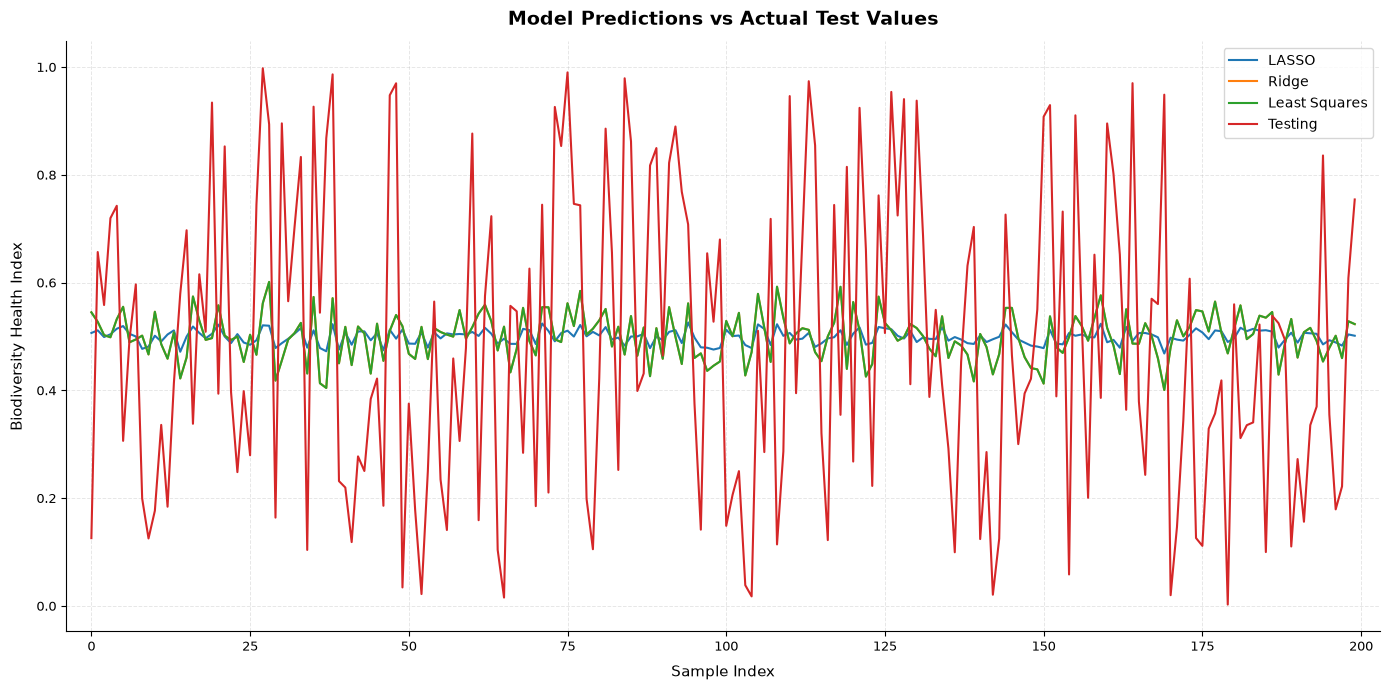

In [27]:
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(y_test))

ax.plot(
    x,
    lasso.predict(X_test),
    label="LASSO"
)

ax.plot(
    x,
    ridge.predict(X_test),
    label="Ridge"
)

ax.plot(
    x,
    lm_all.predict(X_test),
    label="Least Squares"
)

ax.plot(
    x,
    y_test.values,
    label="Testing"
)

style_plot(
    ax,
    title="Model Predictions vs Actual Test Values",
    xlabel="Sample Index",
    ylabel="Biodiversity Health Index",
    grid=True
)

ax.legend()

plt.tight_layout()
plt.show()

In [30]:
from IPython.display import YouTubeVideo

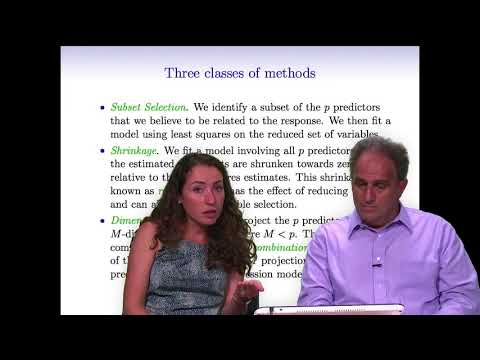

In [33]:
YouTubeVideo("XgNub00Uovs")

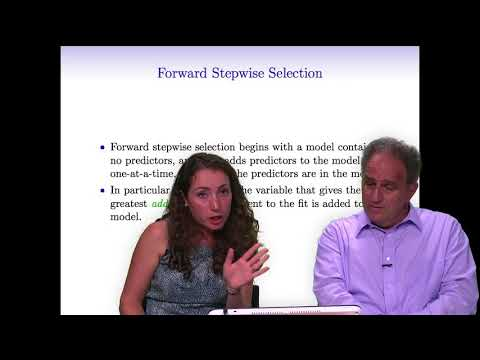

In [34]:
YouTubeVideo("3WA-UjeTdQM")

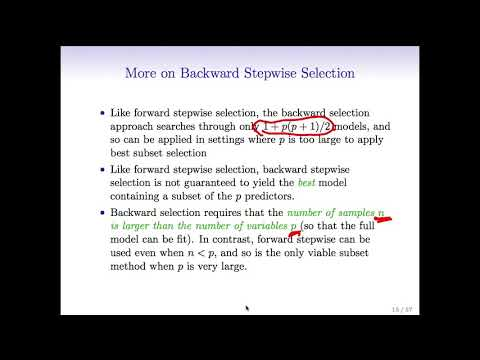

In [32]:
YouTubeVideo("JNTe6T26xss")

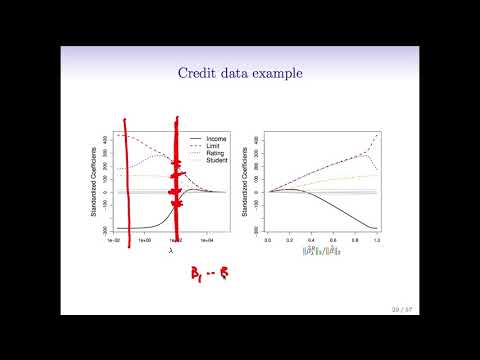

In [29]:
YouTubeVideo("I8bPQ272Pbs")

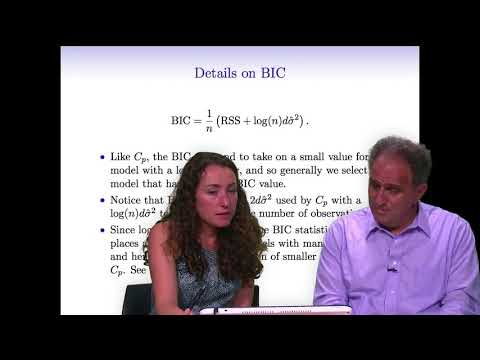

In [31]:
YouTubeVideo("WWuvcg23O_M")